
# Графики для `suite_result.json`

Ноутбук читает JSON с агрегированными метриками и строит **6 основных фигур**:

1. Боксплоты по \(\lambda\) и типам входного потока
2. Декомпозицию отказов
3. Оценку стационарного распределения \(\pi(k)\) в логарифмической шкале
4. Сводные столбчатые панели
5. Сравнительные панели по метрикам
6. Тепловые карты относительных отличий от `poisson`

`02_metric_heatmaps` здесь сознательно убран.


In [55]:

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)


## 1. Конфиг

In [56]:

# --- Путь к JSON ---
JSON_PATH = Path(r"C:\Users\kotof\Study\Diploma\prog_GPU\results\20260426_011853__baseline_gpu\suite_result.json")
# пример для Windows:
# JSON_PATH = Path(r"C:\Users\kotof\Study\Diploma\prog_GPU\results\20260426_011853__baseline_gpu\suite_result.json")

# --- Основные фильтры ---
PREFERRED_WORKLOAD = "exponential"   # если такого workload нет, будет взят первый доступный
PREFERRED_SIGMA = 1.2                 # если такого sigma нет, будет взят первый доступный
SELECTED_ARRIVALS = ["poisson", "erlang_2", "erlang_4", "hyperexp_2"]
SELECTED_LAMBDAS = None               # например [70, 82.2, 90]

# --- Подписи ---
ARRIVAL_LABELS_SHORT = {
    "poisson": "P",
    "erlang_2": "E2",
    "erlang_4": "E4",
    "hyperexp_2": "H2",
}
ARRIVAL_LABELS_FULL = {
    "poisson": "poisson",
    "erlang_2": "erlang_2",
    "erlang_4": "erlang_4",
    "hyperexp_2": "hyperexp_2",
}

METRIC_TITLES = {
    "loss_probability": "Вероятность отказа",
    "throughput": "Пропускная способность",
    "mean_num_jobs": "Среднее число заявок",
    "mean_occupied_resource": "Средний занятый ресурс",
    "mean_service_time": "Среднее время обслуживания",
    "mean_sojourn_time": "Среднее время пребывания",
}

METRIC_YLABELS = {
    "loss_probability": "Вероятность отказа [доля]",
    "throughput": "Пропускная способность [заявки / ед. времени]",
    "mean_num_jobs": "Среднее число заявок",
    "mean_occupied_resource": "Средний занятый ресурс [ед. ресурса]",
    "mean_service_time": "Среднее время обслуживания [ед. времени]",
    "mean_sojourn_time": "Среднее время пребывания [ед. времени]",
}


## 2. Загрузка JSON

In [57]:

with JSON_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

print("suite_name:", raw.get("suite_name"))
print("created_at:", raw.get("created_at"))
print("scenario count:", len(raw.get("scenario_results", {})))
print("ci_level:", raw.get("ci_level"))


suite_name: baseline_gpu
created_at: 2026-04-26T01:18:52
scenario count: 12
ci_level: 0.95


## 3. Разбор JSON в таблицы

In [58]:

def parse_num_token(token: str):
    token = token.replace("p", ".")
    return float(token) if "." in token else int(token)

SCENARIO_RE = re.compile(
    r"arrival__arr-(?P<arrival>.+?)__work-(?P<workload>.+?)__lam-(?P<lam>[\dp]+)__sig-(?P<sig>[\dp]+)$"
)

def parse_scenario_key(scenario_key: str) -> dict:
    m = SCENARIO_RE.match(scenario_key)
    if not m:
        return {
            "arrival": None,
            "workload": None,
            "lambda_value": None,
            "sigma": None,
        }
    return {
        "arrival": m.group("arrival"),
        "workload": m.group("workload"),
        "lambda_value": parse_num_token(m.group("lam")),
        "sigma": parse_num_token(m.group("sig")),
    }

metric_rows = []
for scenario_key, scenario_data in raw.get("scenario_results", {}).items():
    meta = parse_scenario_key(scenario_key)
    scenario_name = scenario_data.get("scenario_name", scenario_key)
    replications = scenario_data.get("replications")

    for metric_name, ms in scenario_data.get("metric_summaries", {}).items():
        metric_rows.append({
            "suite_name": raw.get("suite_name"),
            "created_at": raw.get("created_at"),
            "scenario_key": scenario_key,
            "scenario_name": scenario_name,
            "replications": replications,
            **meta,
            "metric": metric_name,
            "n": ms.get("n"),
            "mean": ms.get("mean"),
            "std": ms.get("std"),
            "stderr": ms.get("stderr"),
            "ci_level": ms.get("ci_level"),
            "ci_low": ms.get("ci_low"),
            "ci_high": ms.get("ci_high"),
            "min_value": ms.get("min_value"),
            "max_value": ms.get("max_value"),
        })

metrics_long_df = pd.DataFrame(metric_rows)
metrics_long_df = metrics_long_df.sort_values(
    ["arrival", "workload", "lambda_value", "sigma", "metric"]
).reset_index(drop=True)

id_cols = [
    "suite_name", "created_at", "scenario_key", "scenario_name", "replications",
    "arrival", "workload", "lambda_value", "sigma"
]
value_fields = ["mean", "std", "stderr", "ci_low", "ci_high", "min_value", "max_value", "n"]

wide_parts = []
for field in value_fields:
    part = metrics_long_df.pivot_table(index=id_cols, columns="metric", values=field, aggfunc="first")
    if len(part.columns) > 0:
        part.columns = [f"{c}__{field}" for c in part.columns]
        wide_parts.append(part)

scenario_df = pd.concat(wide_parts, axis=1).reset_index()

z_value = 1.959963984540054

# Производные метрики: throughput = L / W
if {"mean_num_jobs__mean", "mean_sojourn_time__mean"}.issubset(scenario_df.columns):
    L = scenario_df["mean_num_jobs__mean"].astype(float)
    W = scenario_df["mean_sojourn_time__mean"].astype(float)
    scenario_df["throughput__mean"] = L / W

    if {"mean_num_jobs__stderr", "mean_sojourn_time__stderr"}.issubset(scenario_df.columns):
        L_se = scenario_df["mean_num_jobs__stderr"].astype(float)
        W_se = scenario_df["mean_sojourn_time__stderr"].astype(float)
        # delta-method, без учета ковариации
        throughput_se = np.sqrt((L_se / W) ** 2 + ((L * W_se) / (W ** 2)) ** 2)
        scenario_df["throughput__stderr"] = throughput_se
        scenario_df["throughput__ci_low"] = scenario_df["throughput__mean"] - z_value * throughput_se
        scenario_df["throughput__ci_high"] = scenario_df["throughput__mean"] + z_value * throughput_se

# Полезные подписи

def fmt_lambda(x):
    x = float(x)
    if x.is_integer():
        return f"λ={int(x)}"
    return f"λ={x:g}"

scenario_df["lambda_label"] = scenario_df["lambda_value"].map(fmt_lambda)
scenario_df["arrival_short"] = scenario_df["arrival"].map(ARRIVAL_LABELS_SHORT).fillna(scenario_df["arrival"])
scenario_df["arrival_full"] = scenario_df["arrival"].map(ARRIVAL_LABELS_FULL).fillna(scenario_df["arrival"])
scenario_df["display_name"] = scenario_df["arrival_short"] + "\n" + scenario_df["lambda_label"]

print("metrics_long_df:", metrics_long_df.shape)
print("scenario_df:", scenario_df.shape)


metrics_long_df: (1356, 19)
scenario_df: (12, 917)


## 4. Выбор рабочего среза

In [59]:

available_workloads = sorted(x for x in scenario_df["workload"].dropna().unique())
available_sigmas = sorted(x for x in scenario_df["sigma"].dropna().unique())
available_lambdas = sorted(x for x in scenario_df["lambda_value"].dropna().unique())
available_arrivals = [x for x in ["poisson", "erlang_2", "erlang_4", "hyperexp_2"] if x in set(scenario_df["arrival"])]

selected_workload = PREFERRED_WORKLOAD if PREFERRED_WORKLOAD in available_workloads else (available_workloads[0] if available_workloads else None)
selected_sigma = PREFERRED_SIGMA if PREFERRED_SIGMA in available_sigmas else (available_sigmas[0] if available_sigmas else None)
selected_arrivals = [x for x in SELECTED_ARRIVALS if x in set(scenario_df["arrival"])] if SELECTED_ARRIVALS else available_arrivals
selected_lambdas = SELECTED_LAMBDAS if SELECTED_LAMBDAS is not None else available_lambdas

plot_df = scenario_df.copy()
if selected_workload is not None:
    plot_df = plot_df[plot_df["workload"] == selected_workload]
if selected_sigma is not None:
    plot_df = plot_df[plot_df["sigma"] == selected_sigma]
if selected_arrivals:
    plot_df = plot_df[plot_df["arrival"].isin(selected_arrivals)]
if selected_lambdas is not None:
    plot_df = plot_df[plot_df["lambda_value"].isin(selected_lambdas)]

arrival_order = [x for x in ["poisson", "erlang_2", "erlang_4", "hyperexp_2"] if x in set(plot_df["arrival"])]
lambda_order = sorted(plot_df["lambda_value"].unique())

print("selected_workload:", selected_workload)
print("selected_sigma:", selected_sigma)
print("arrival_order:", arrival_order)
print("lambda_order:", lambda_order)
print("plot_df shape:", plot_df.shape)

display(plot_df[["arrival", "workload", "lambda_value", "sigma", "display_name"]].sort_values(["arrival", "lambda_value"]).reset_index(drop=True))


selected_workload: exponential
selected_sigma: 1.2
arrival_order: ['poisson', 'erlang_2', 'erlang_4', 'hyperexp_2']
lambda_order: [np.float64(70.0), np.float64(82.2), np.float64(90.0)]
plot_df shape: (12, 917)


,arrival,workload,lambda_value,sigma,display_name
0,erlang_2,exponential,70.0,1.2,E2\nλ=70
1,erlang_2,exponential,82.2,1.2,E2\nλ=82.2
2,erlang_2,exponential,90.0,1.2,E2\nλ=90
3,erlang_4,exponential,70.0,1.2,E4\nλ=70
4,erlang_4,exponential,82.2,1.2,E4\nλ=82.2
5,erlang_4,exponential,90.0,1.2,E4\nλ=90
6,hyperexp_2,exponential,70.0,1.2,H2\nλ=70
7,hyperexp_2,exponential,82.2,1.2,H2\nλ=82.2
8,hyperexp_2,exponential,90.0,1.2,H2\nλ=90
9,poisson,exponential,70.0,1.2,P\nλ=70


## 5. Вспомогательные функции

In [60]:

def ordered_subset(df: pd.DataFrame) -> pd.DataFrame:
    arr_rank = {a: i for i, a in enumerate(arrival_order)}
    lam_rank = {l: i for i, l in enumerate(lambda_order)}
    tmp = df.copy()
    tmp["_arr_rank"] = tmp["arrival"].map(arr_rank)
    tmp["_lam_rank"] = tmp["lambda_value"].map(lam_rank)
    tmp = tmp.sort_values(["_arr_rank", "_lam_rank"]).drop(columns=["_arr_rank", "_lam_rank"])
    return tmp


def metric_col(metric: str, suffix: str) -> str:
    return f"{metric}__{suffix}"


def get_metric_arrays(df: pd.DataFrame, metric: str):
    mean_col = metric_col(metric, "mean")
    lo_col = metric_col(metric, "ci_low")
    hi_col = metric_col(metric, "ci_high")
    if mean_col not in df.columns:
        raise KeyError(f"Не найден столбец {mean_col}")
    means = df[mean_col].astype(float).values
    lows = df[lo_col].astype(float).values if lo_col in df.columns else np.full(len(df), np.nan)
    highs = df[hi_col].astype(float).values if hi_col in df.columns else np.full(len(df), np.nan)
    return means, lows, highs


def build_metric_pivot(df: pd.DataFrame, metric: str, value_suffix: str = "mean") -> pd.DataFrame:
    col = metric_col(metric, value_suffix)
    if col not in df.columns:
        raise KeyError(f"Не найден столбец {col}")
    out = (
        df.pivot_table(index="arrival", columns="lambda_value", values=col, aggfunc="first")
          .reindex(index=arrival_order, columns=lambda_order)
    )
    return out


def draw_annotated_heatmap(ax, data: pd.DataFrame, title: str, fmt: str = ".4f", cmap: str = "Greys", center_zero: bool = False):
    arr = data.values.astype(float)
    if center_zero:
        vmax = np.nanmax(np.abs(arr)) if np.isfinite(arr).any() else 1.0
        vmin = -vmax
    else:
        vmin = np.nanmin(arr) if np.isfinite(arr).any() else 0.0
        vmax = np.nanmax(arr) if np.isfinite(arr).any() else 1.0

    im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=16, weight="bold")
    ax.set_xlabel("lambda")
    ax.set_ylabel("arrival")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels([fmt_lambda(x) for x in data.columns])
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(list(data.index))

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data.iloc[i, j]
            if pd.notna(val):
                txt = format(val, fmt) if fmt not in {"+,.2f", "+.2f"} else format(val, fmt)
                ax.text(j, i, txt, ha="center", va="center", fontsize=10)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)


def synthetic_samples(mean, std, n, min_value=None, max_value=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    if pd.isna(mean):
        return np.array([])
    if pd.isna(n) or int(n) <= 1:
        n = 50
    else:
        n = int(n)
    if pd.isna(std) or std == 0:
        return np.repeat(mean, n)

    samples = rng.normal(loc=mean, scale=std, size=n)
    if min_value is not None and pd.notna(min_value):
        samples = np.maximum(samples, float(min_value))
    if max_value is not None and pd.notna(max_value):
        samples = np.minimum(samples, float(max_value))
    return samples


## 6. График 1 — боксплоты

Ниже каждый ряд вынесен в отдельную ячейку. Внутри каждой фигуры панели расположены как \(2 \times 2\).

In [61]:

def plot_metric_boxpanel_single(df: pd.DataFrame, metric: str):
    rng = np.random.default_rng(42)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), squeeze=False)
    axes = axes.ravel()

    for ax, arrival in zip(axes, arrival_order):
        arr_df = df[df["arrival"] == arrival].sort_values("lambda_value")

        data_for_boxes = []
        labels = []
        for lam in lambda_order:
            row = arr_df[arr_df["lambda_value"] == lam]
            if row.empty:
                continue
            row = row.iloc[0]
            samples = synthetic_samples(
                row.get(metric_col(metric, "mean")),
                row.get(metric_col(metric, "std")),
                row.get(metric_col(metric, "n")),
                row.get(metric_col(metric, "min_value")),
                row.get(metric_col(metric, "max_value")),
                rng=rng,
            )
            if len(samples) > 0:
                data_for_boxes.append(samples)
                labels.append(fmt_lambda(lam))

        if data_for_boxes:
            ax.boxplot(data_for_boxes, labels=labels)

        ax.set_title(f"{METRIC_TITLES[metric]}\narrival={arrival}", fontsize=15, weight="bold")
        ax.set_ylabel(METRIC_YLABELS[metric])
        ax.set_xlabel("lambda")

    for ax in axes[len(arrival_order):]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()


C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_

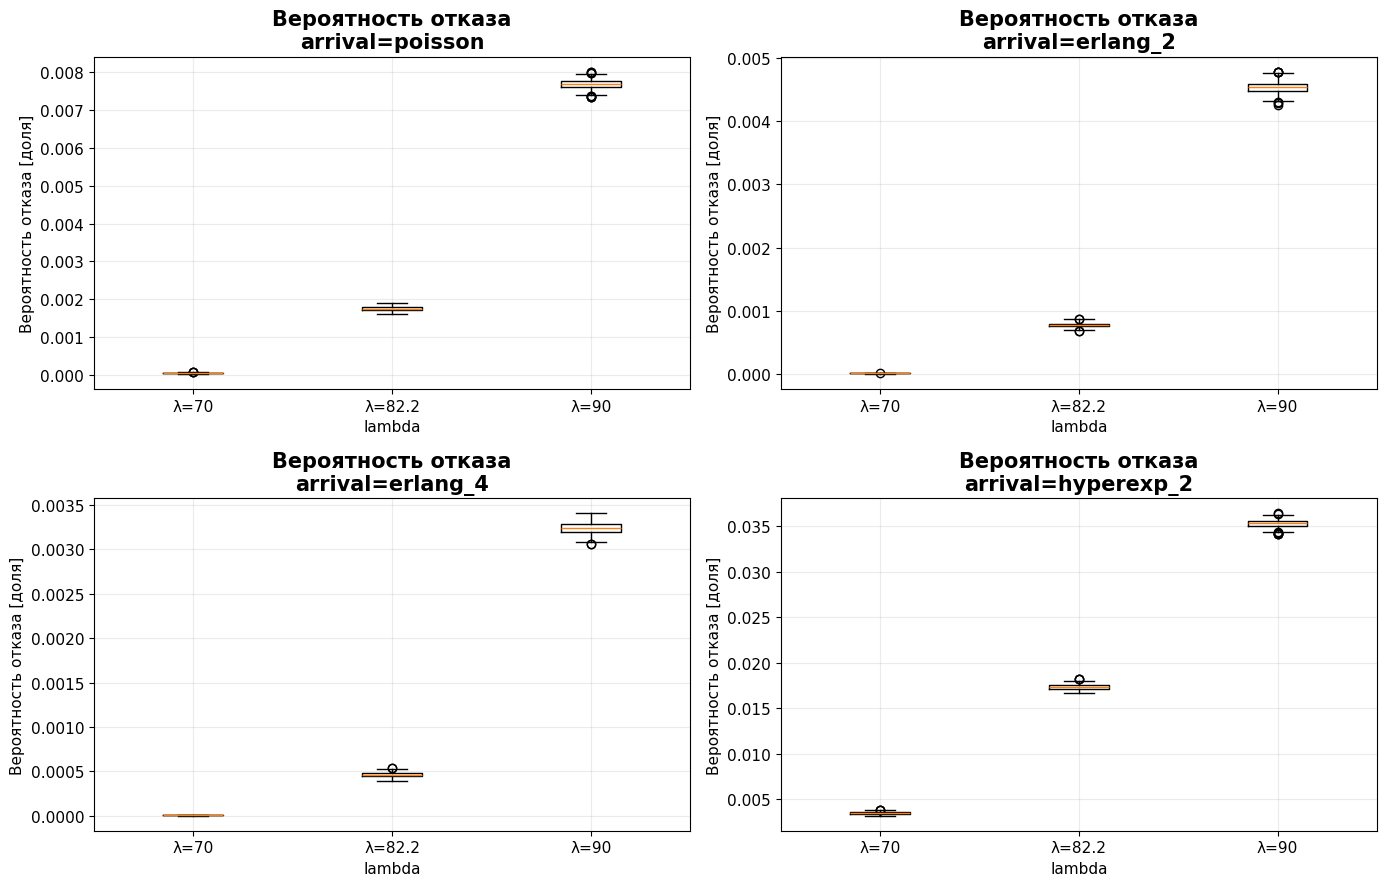

In [62]:
plot_metric_boxpanel_single(plot_df, "loss_probability")

C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_

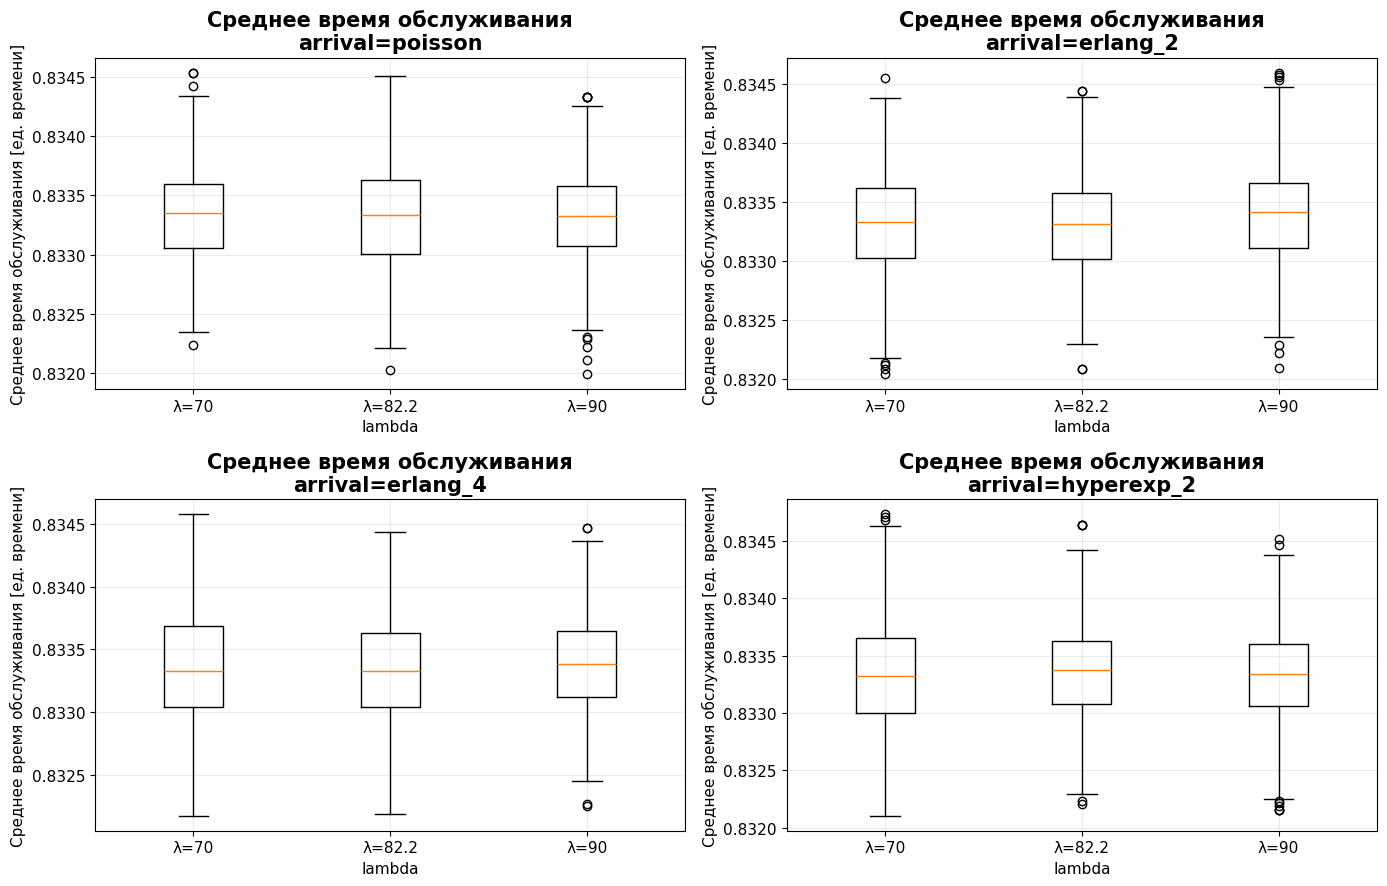

In [63]:
plot_metric_boxpanel_single(plot_df, "mean_service_time")

C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_for_boxes, labels=labels)
C:\Users\kotof\AppData\Local\Temp\ipykernel_32536\2918993261.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_

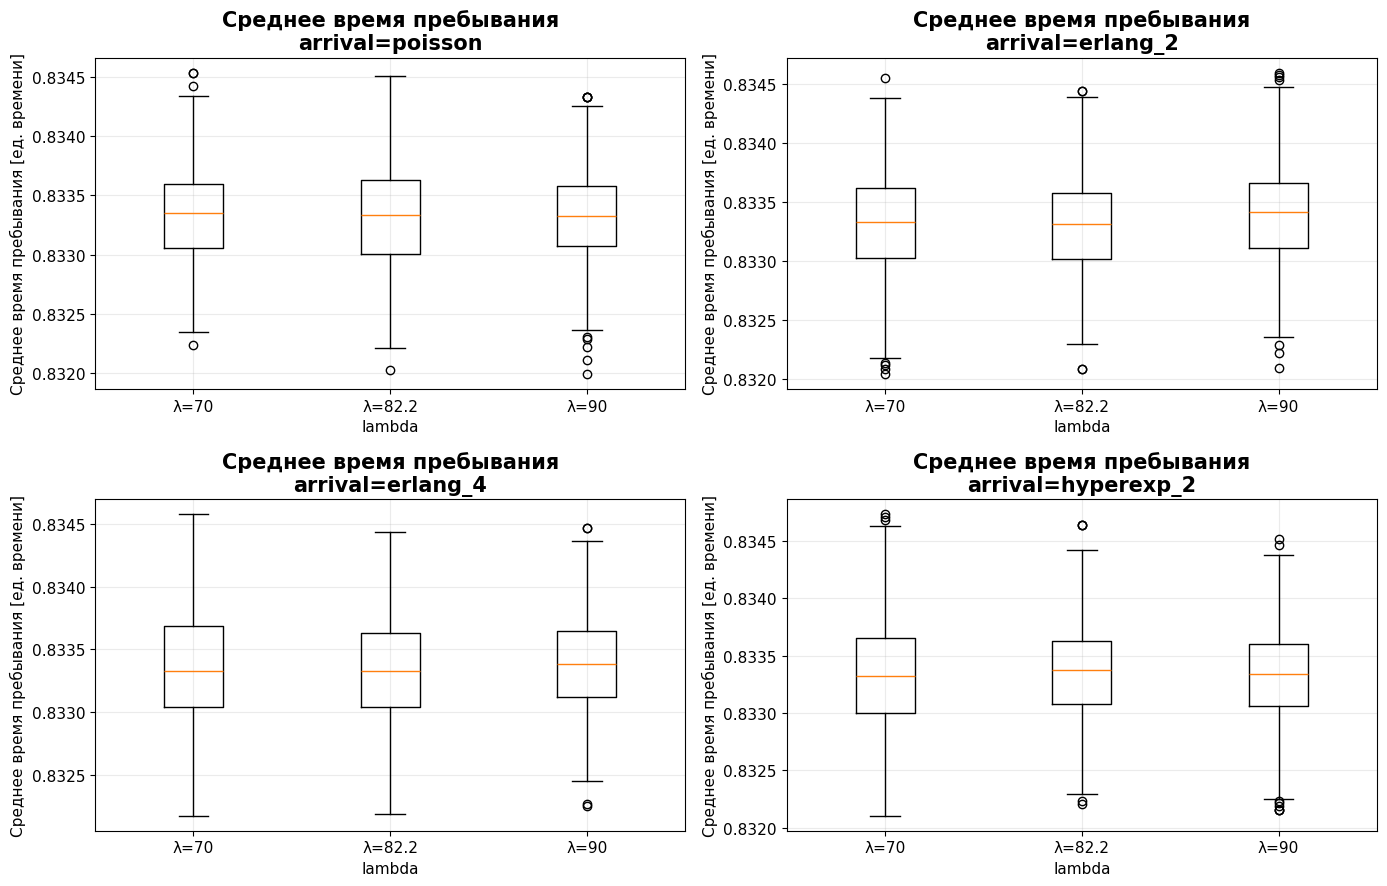

In [64]:
plot_metric_boxpanel_single(plot_df, "mean_sojourn_time")

## 7. График 2 — декомпозиция отказов

capacity metric: None
servers metric: None
resource metric: None


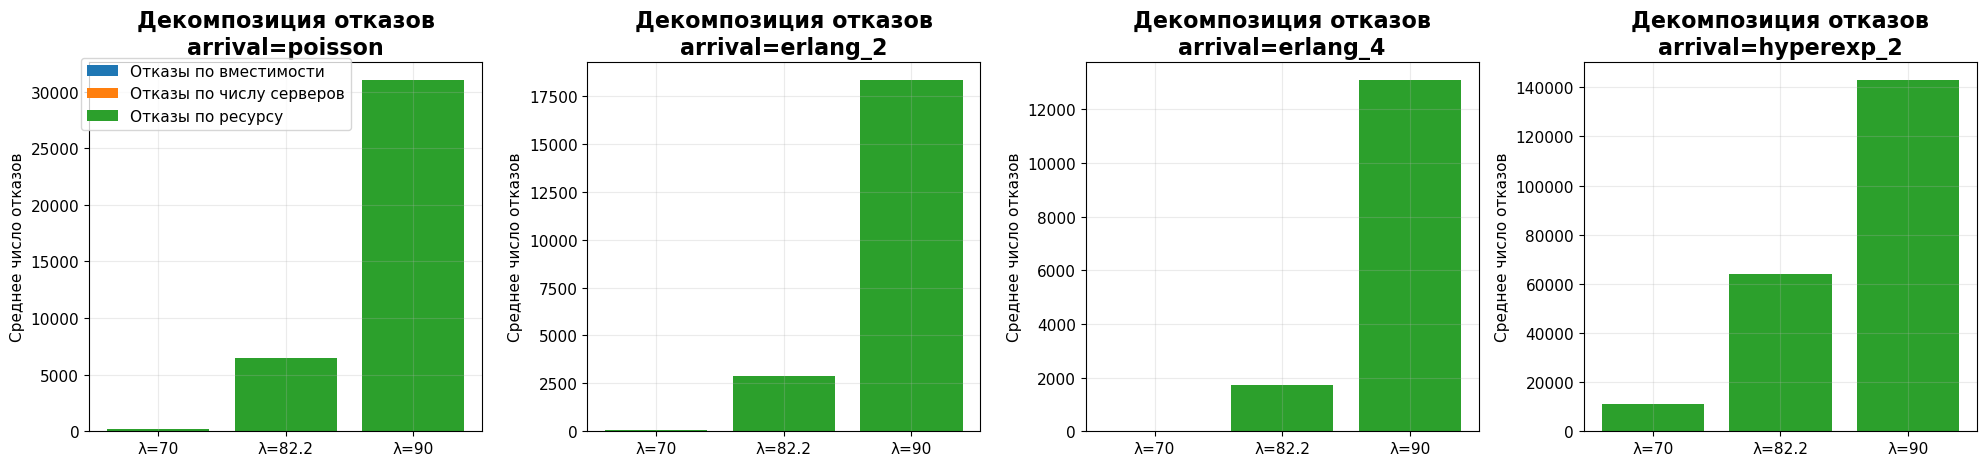

In [65]:

DECOMP_CANDIDATES = {
    "capacity": [
        "rejected_by_capacity", "rejections_by_capacity", "blocked_by_capacity",
        "rejected_system_capacity", "rejected_by_system_capacity",
        "capacity_rejections", "rejected_due_to_capacity"
    ],
    "servers": [
        "rejected_by_servers", "rejections_by_servers", "blocked_by_servers",
        "rejected_by_server_count", "rejected_due_to_servers", "server_rejections"
    ],
    "resource": [
        "rejected_by_resource", "rejections_by_resource", "blocked_by_resource",
        "resource_rejections", "rejected_due_to_resource"
    ],
}

available_metric_names = set(m.replace("__mean", "") for m in scenario_df.columns if m.endswith("__mean"))

def pick_metric_name(candidates):
    for name in candidates:
        if name in available_metric_names:
            return name
    return None

capacity_metric = pick_metric_name(DECOMP_CANDIDATES["capacity"])
servers_metric = pick_metric_name(DECOMP_CANDIDATES["servers"])
resource_metric = pick_metric_name(DECOMP_CANDIDATES["resource"])

print("capacity metric:", capacity_metric)
print("servers metric:", servers_metric)
print("resource metric:", resource_metric)


def plot_rejection_decomposition(df: pd.DataFrame):
    fig, axes = plt.subplots(1, len(arrival_order), figsize=(20, 4.8), squeeze=False)
    axes = axes[0]

    for ax, arrival in zip(axes, arrival_order):
        sub = df[df["arrival"] == arrival].sort_values("lambda_value")
        x = np.arange(len(lambda_order))

        total_rej = (sub["arrival_attempts__mean"] - sub["accepted_arrivals__mean"]).astype(float).values
        cap = sub[metric_col(capacity_metric, "mean")].astype(float).values if capacity_metric else np.zeros(len(sub))
        srv = sub[metric_col(servers_metric, "mean")].astype(float).values if servers_metric else np.zeros(len(sub))
        res = sub[metric_col(resource_metric, "mean")].astype(float).values if resource_metric else np.zeros(len(sub))

        known_sum = cap + srv + res
        residual = total_rej - known_sum
        residual = np.where(residual > 0, residual, 0.0)
        res = res + residual

        ax.bar(x, cap, label="Отказы по вместимости")
        ax.bar(x, srv, bottom=cap, label="Отказы по числу серверов")
        ax.bar(x, res, bottom=cap + srv, label="Отказы по ресурсу")

        ax.set_xticks(x)
        ax.set_xticklabels([fmt_lambda(l) for l in lambda_order])
        ax.set_title(f"Декомпозиция отказов\narrival={arrival}", fontsize=16, weight="bold")
        ax.set_ylabel("Среднее число отказов")

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.04, 0.88))

    fig.tight_layout()
    plt.show()

plot_rejection_decomposition(plot_df)


## 8. График 3 — стационарное распределение

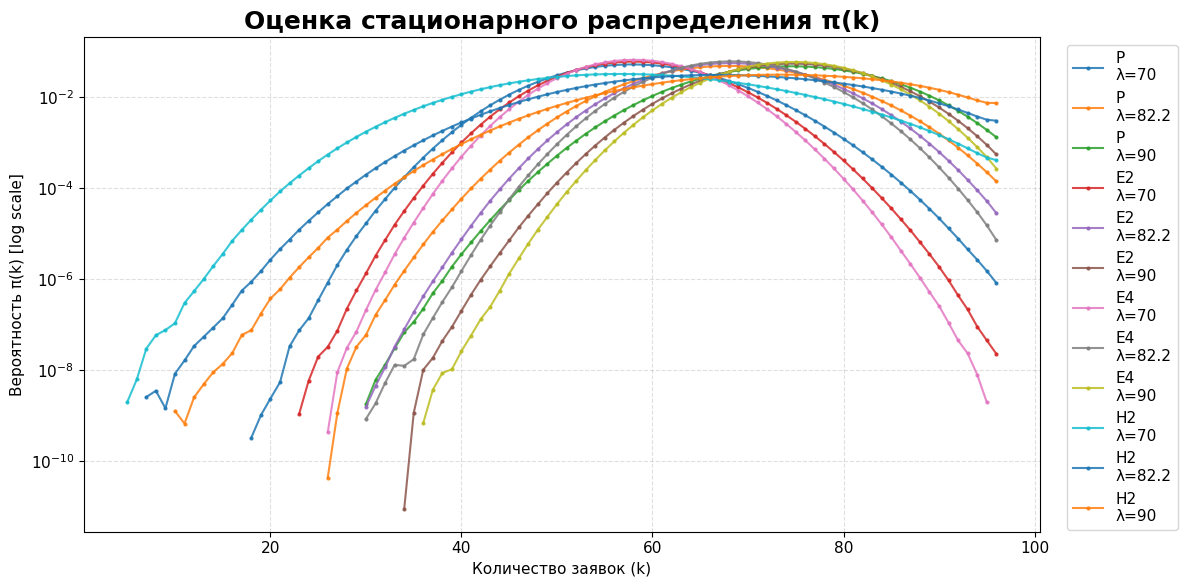

In [66]:

def plot_stationary_distribution(df: pd.DataFrame):
    pi_cols = [c for c in df.columns if c.startswith("pi_hat_") and c.endswith("__mean")]
    if not pi_cols:
        print("Метрики pi_hat_k не найдены.")
        return

    k_vals_and_cols = []
    for c in pi_cols:
        match = re.search(r"pi_hat_(\d+)__mean", c)
        if match:
            k_vals_and_cols.append((int(match.group(1)), c))

    k_vals_and_cols.sort(key=lambda x: x[0])
    k_values = [x[0] for x in k_vals_and_cols]
    ordered_cols = [x[1] for x in k_vals_and_cols]

    df = ordered_subset(df)

    fig, ax = plt.subplots(figsize=(12, 6))
    for _, row in df.iterrows():
        y = row[ordered_cols].astype(float).values
        y = np.where(y > 0, y, np.nan)
        ax.plot(k_values, y, marker=".", markersize=4, label=row["display_name"], alpha=0.85)

    ax.set_title("Оценка стационарного распределения π(k)", fontsize=18, weight="bold")
    ax.set_xlabel("Количество заявок (k)")
    ax.set_ylabel("Вероятность π(k) [log scale]")
    ax.set_yscale("log")
    ax.grid(True, which="both", ls="--", alpha=0.4)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

plot_stationary_distribution(plot_df)


## 9. График 4 — сводные столбчатые панели

Каждая метрика теперь выводится отдельной ячейкой.

In [67]:

def plot_summary_bar_metric(df: pd.DataFrame, metric: str):
    df = ordered_subset(df)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(df))
    labels = df["display_name"].tolist()

    means, lows, highs = get_metric_arrays(df, metric)
    yerr = None
    if np.isfinite(lows).any() and np.isfinite(highs).any():
        lower = means - lows
        upper = highs - means
        yerr = np.vstack([lower, upper])

    ax.bar(x, means, yerr=yerr, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(METRIC_TITLES[metric], fontsize=16, weight="bold")
    ax.set_ylabel(METRIC_YLABELS[metric])

    fig.tight_layout()
    plt.show()


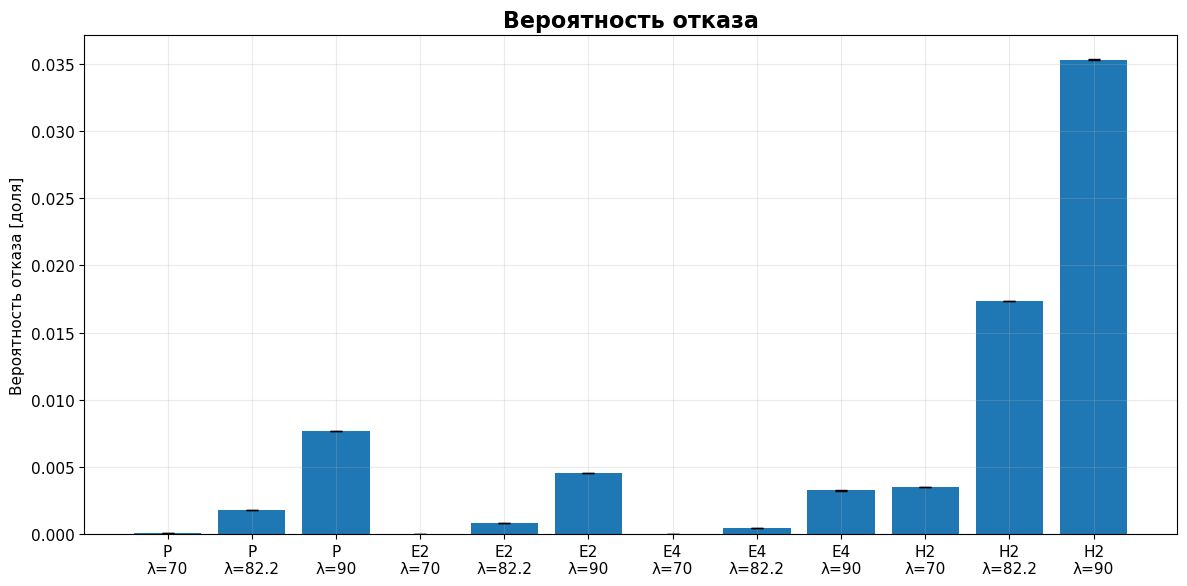

In [68]:
plot_summary_bar_metric(plot_df, "loss_probability")

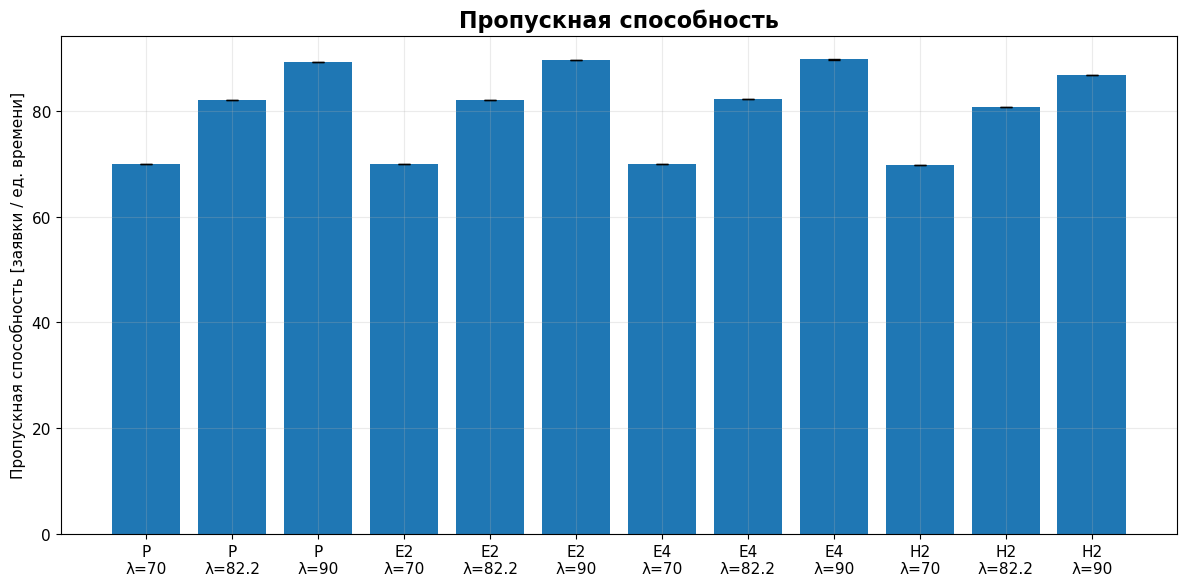

In [69]:
plot_summary_bar_metric(plot_df, "throughput")

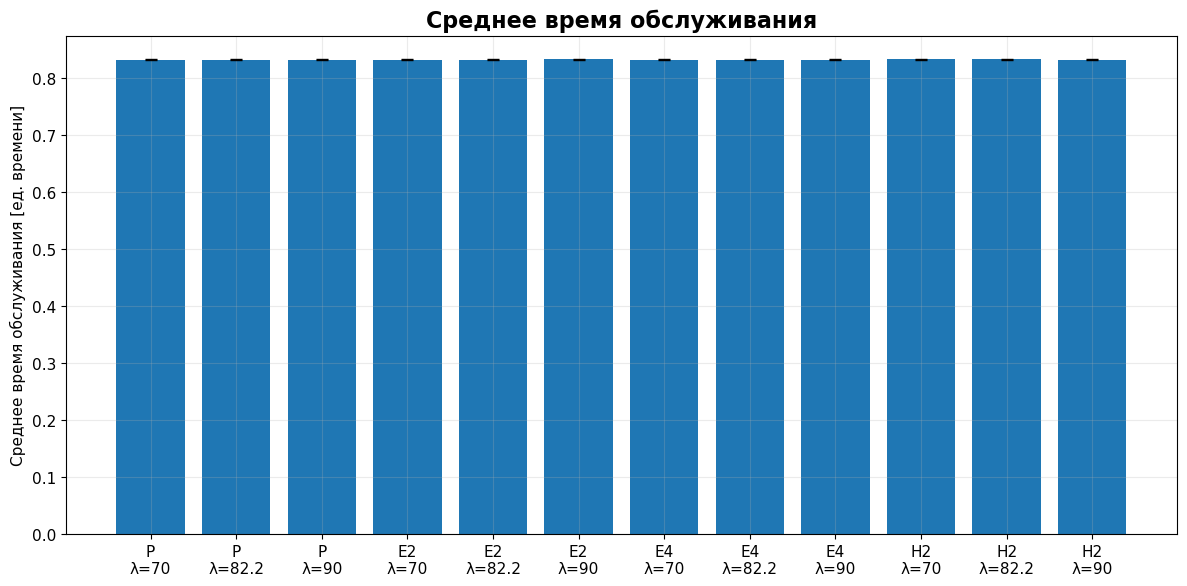

In [70]:
plot_summary_bar_metric(plot_df, "mean_service_time")

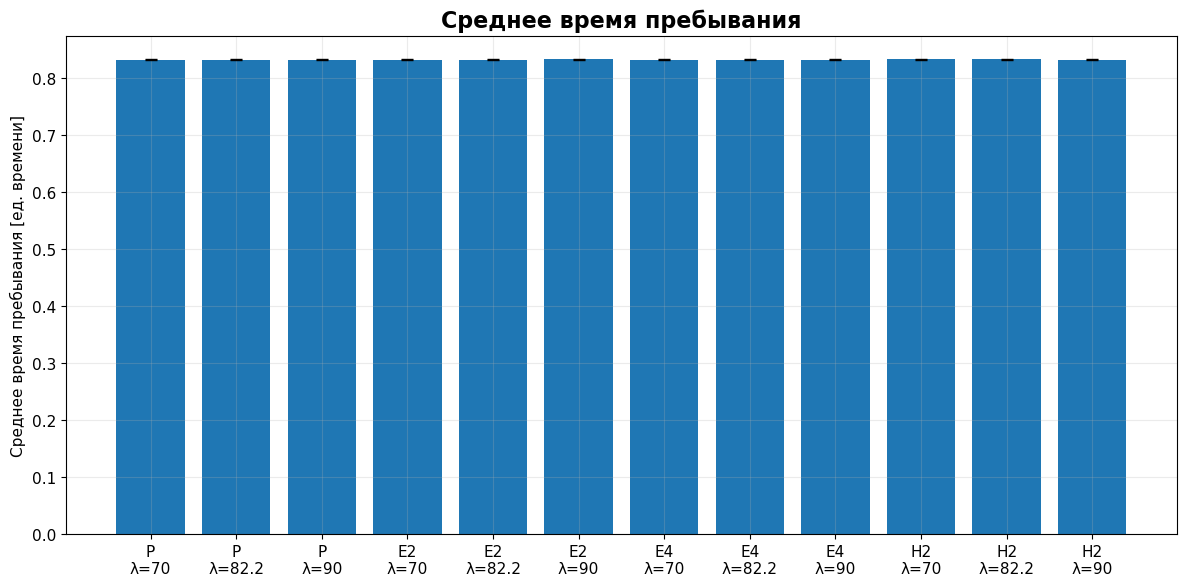

In [71]:
plot_summary_bar_metric(plot_df, "mean_sojourn_time")

## 10. График 5 — аккуратные сравнительные панели

Каждая метрика теперь вынесена в отдельную ячейку.

In [72]:

def plot_comparative_metric(df: pd.DataFrame, metric: str):
    fig, ax = plt.subplots(figsize=(10, 6))

    for arrival in arrival_order:
        sub = df[df["arrival"] == arrival].sort_values("lambda_value")
        if sub.empty:
            continue

        means, lows, highs = get_metric_arrays(sub, metric)
        yerr = None
        if np.isfinite(lows).any() and np.isfinite(highs).any():
            yerr = np.vstack([means - lows, highs - means])

        ax.errorbar(
            sub["lambda_value"].values,
            means,
            yerr=yerr,
            marker="o",
            capsize=3,
            label=arrival,
        )

        for x_i, y_i in zip(sub["lambda_value"].values, means):
            if pd.notna(y_i):
                label_text = f"{y_i:.4f}" if abs(float(y_i)) < 1 else f"{y_i:.2f}"
                ax.annotate(label_text, (x_i, y_i), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

    ax.set_title(METRIC_TITLES[metric], fontsize=16, weight="bold")
    ax.set_xlabel("Интенсивность поступления λ")
    ax.set_ylabel(METRIC_YLABELS[metric])
    ax.legend(title="arrival")

    fig.tight_layout()
    plt.show()


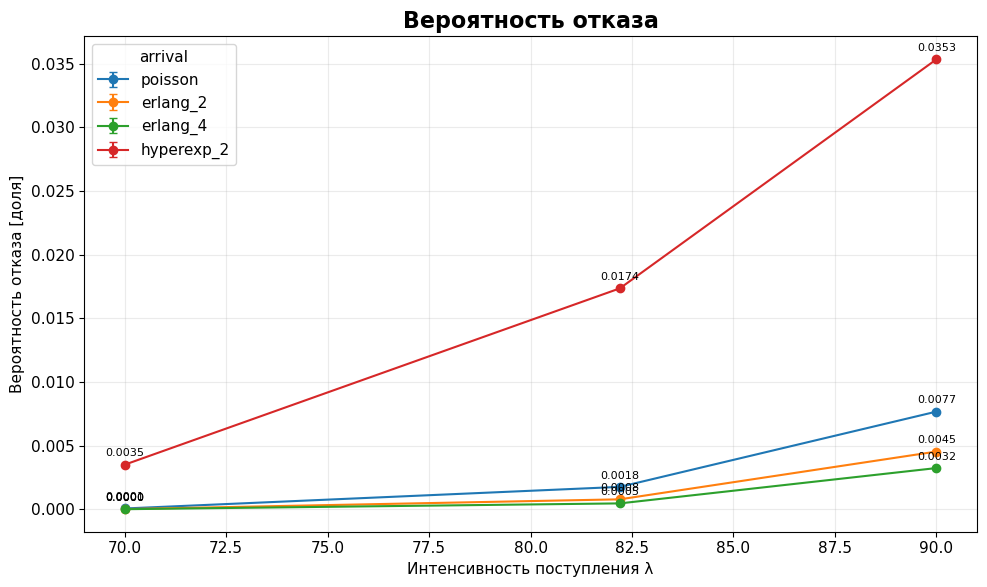

In [73]:
plot_comparative_metric(plot_df, "loss_probability")

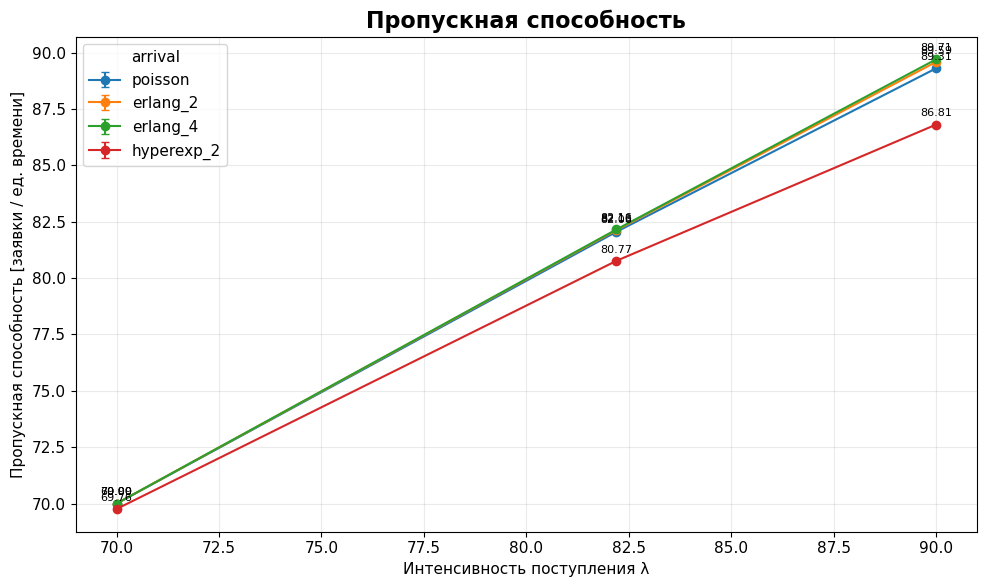

In [74]:
plot_comparative_metric(plot_df, "throughput")

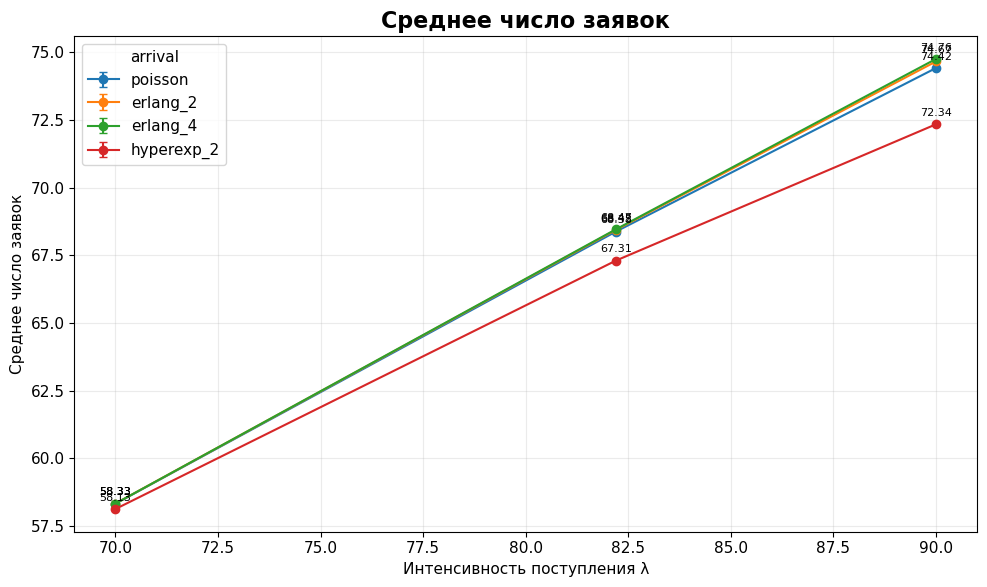

In [75]:
plot_comparative_metric(plot_df, "mean_num_jobs")

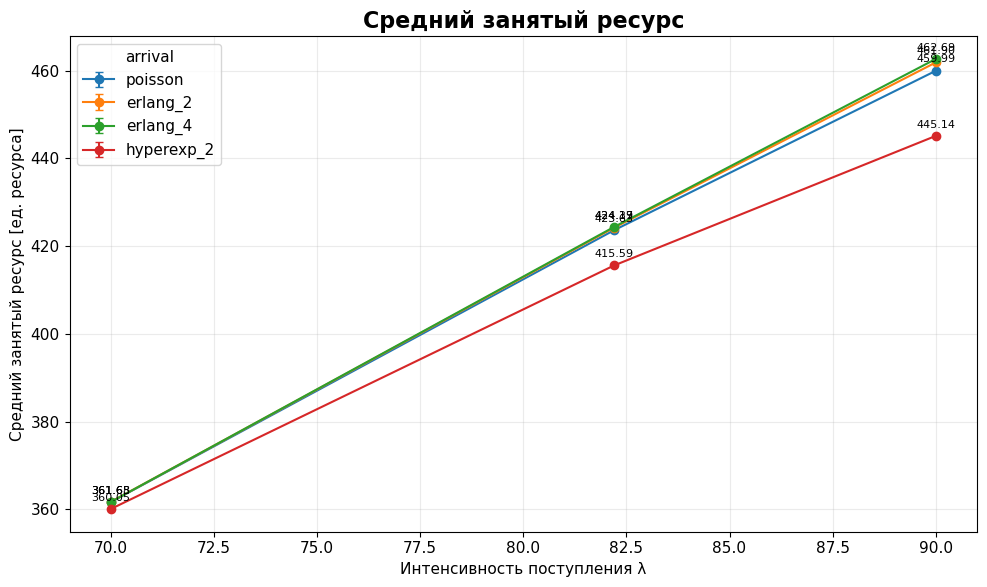

In [76]:
plot_comparative_metric(plot_df, "mean_occupied_resource")

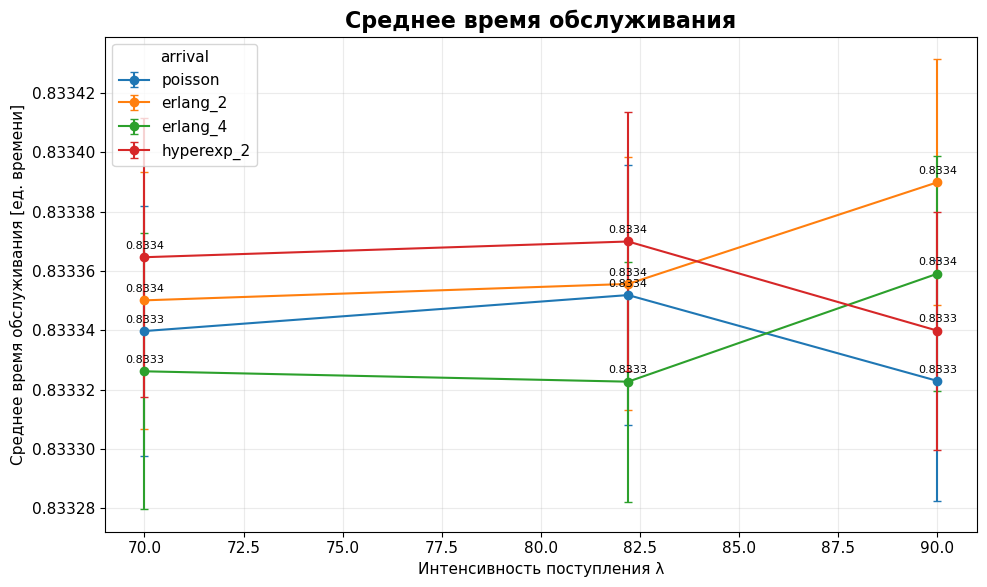

In [77]:
plot_comparative_metric(plot_df, "mean_service_time")

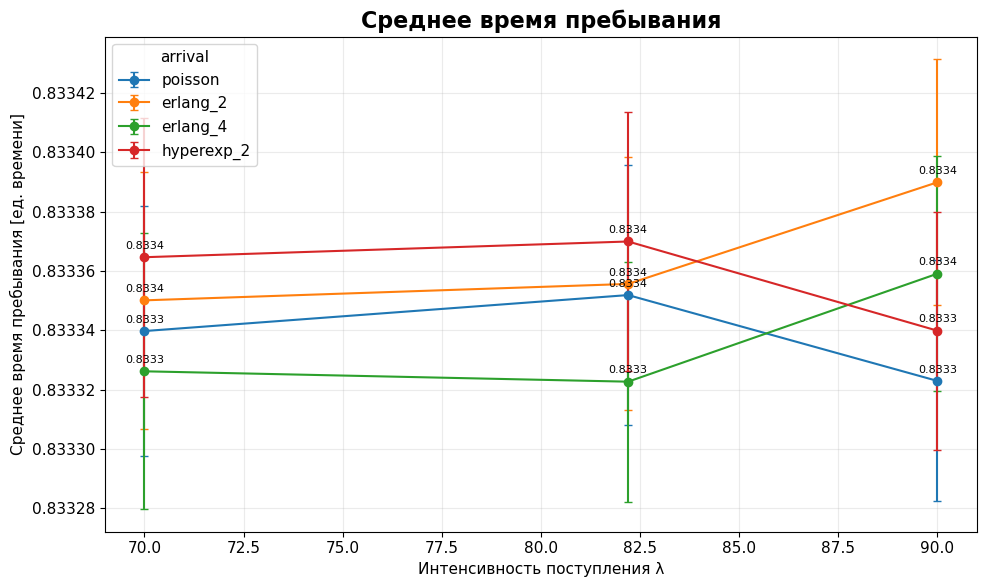

In [78]:
plot_comparative_metric(plot_df, "mean_sojourn_time")

## 11. График 6 — относительные отличия от `poisson`

Тепловые карты собраны в компактный формат \(2 \times 2\).

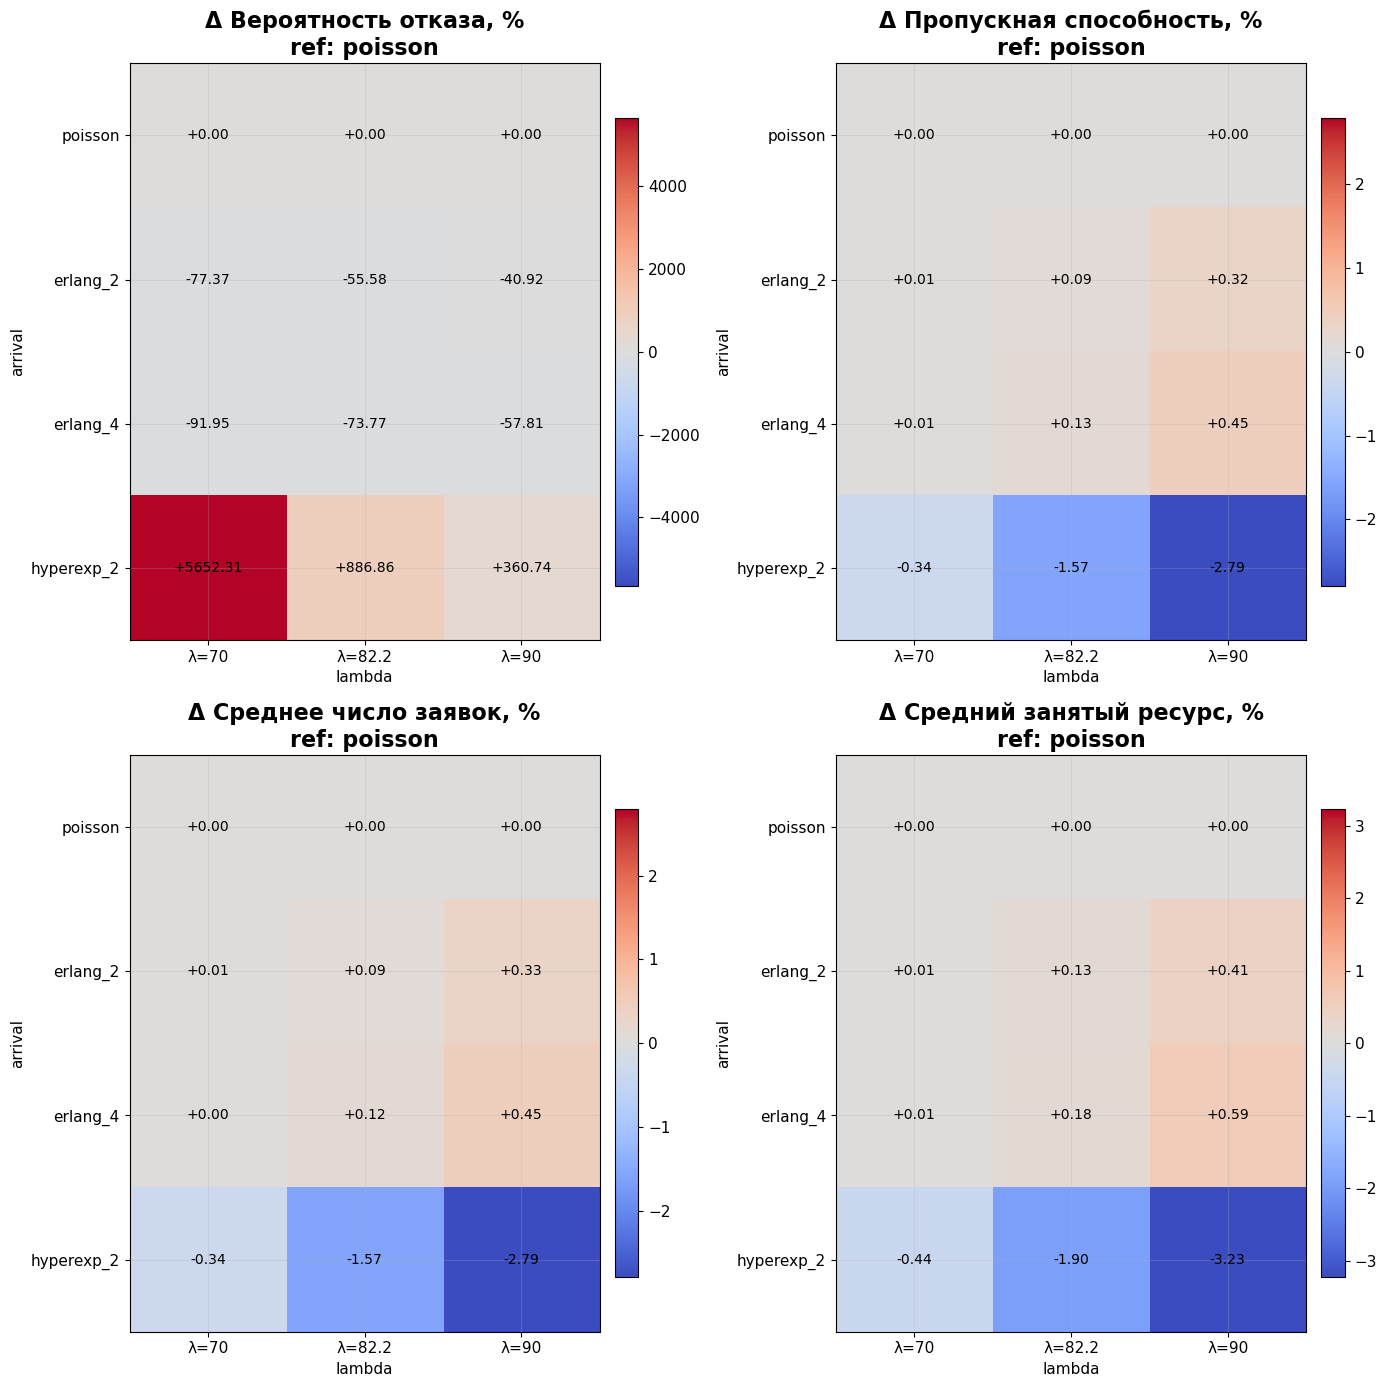

In [79]:

def plot_delta_heatmaps(df: pd.DataFrame):
    metrics = ["loss_probability", "throughput", "mean_num_jobs", "mean_occupied_resource"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 14), squeeze=False)
    axes = axes.ravel()

    for ax, metric in zip(axes, metrics):
        pivot = build_metric_pivot(df, metric, value_suffix="mean")
        if "poisson" not in pivot.index:
            ax.text(0.5, 0.5, "Нет строки 'poisson' для сравнения", ha="center", va="center")
            ax.axis("off")
            continue

        ref = pivot.loc["poisson"]
        delta = (pivot.divide(ref, axis=1) - 1.0) * 100.0
        delta = delta.replace([np.inf, -np.inf], np.nan)

        draw_annotated_heatmap(
            ax,
            delta,
            title=f"Δ {METRIC_TITLES[metric]}, %\nref: poisson",
            fmt="+.2f",
            cmap="coolwarm",
            center_zero=True,
        )

    fig.tight_layout()
    plt.show()

plot_delta_heatmaps(plot_df)



## Что менять дальше

Если захочешь быстро подстроить ноутбук под свой JSON:

- поменяй `JSON_PATH`
- при необходимости выставь `PREFERRED_WORKLOAD`
- при необходимости выставь `PREFERRED_SIGMA`
- если нужно ограничить только тремя значениями \(\lambda\), задай `SELECTED_LAMBDAS = [70, 82.2, 90]`

Если у тебя в JSON другие названия метрик декомпозиции отказов, поправь словарь `DECOMP_CANDIDATES`.
